In [1]:
!pip install earthengine-api geemap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.8 MB/s eta 0:00:00


In [2]:
import ee
import geemap
import pandas as pd

ee.Authenticate()
ee.Initialize(project='ee-chanita')

In [3]:
provinces = ee.FeatureCollection("FAO/GAUL/2015/level1")

buriram = provinces \
    .filter(ee.Filter.eq('ADM0_NAME','Thailand')) \
    .filter(ee.Filter.eq('ADM1_NAME','Buriram'))

roi = buriram.geometry()

In [4]:
def mask_clouds(image):
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8))
    return image.updateMask(mask)

In [5]:
def add_indices(image):

    ndvi = image.normalizedDifference(['B8','B4']).rename('NDVI')

    ndmi = image.normalizedDifference(['B8','B11']).rename('NDMI')

    ndwi = image.normalizedDifference(['B3','B8']).rename('NDWI')

    return image.addBands([ndvi, ndmi, ndwi])

In [6]:
rainy = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(roi) \
    .filterDate('2020-08-01','2020-10-31') \
    .map(mask_clouds) \
    .median() \
    .clip(roi)

dry = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(roi) \
    .filterDate('2020-02-01','2020-04-30') \
    .map(mask_clouds) \
    .median() \
    .clip(roi)

In [7]:
rainy = add_indices(rainy)
dry = add_indices(dry)

In [8]:
ndvi_change = rainy.select('NDVI').subtract(dry.select('NDVI'))

ndmi_change = rainy.select('NDMI').subtract(dry.select('NDMI'))

ndwi_change = rainy.select('NDWI').subtract(dry.select('NDWI'))

In [9]:
drought_risk = dry.select('NDVI').lt(0.3) \
    .And(dry.select('NDMI').lt(0)) \
    .clip(roi)

In [10]:
water = dry.select('NDWI').gt(0.3).clip(roi)

moist_area = dry.select('NDMI').gt(0.2).clip(roi)

In [11]:
Map = geemap.Map(center=[14.99,103.1], zoom=9)

Map.addLayer(
    dry.select('NDVI'),
    {'min':-1,'max':1,'palette':['brown','yellow','green']},
    'NDVI Dry'
)

Map.addLayer(
    ndvi_change,
    {'min':-1,'max':1,'palette':['red','white','green']},
    'NDVI Change'
)

Map.addLayer(
    drought_risk.updateMask(drought_risk),
    {'palette':['red']},
    'Drought Risk'
)

Map.addLayer(
    water.updateMask(water),
    {'palette':['blue']},
    'Water'
)

Map.addLayer(
    moist_area.updateMask(moist_area),
    {'palette':['cyan']},
    'Moist Area'
)

Map.addLayer(buriram,{'color':'black'},'Buriram')

Map

Map(center=[14.99, 103.1], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

In [12]:
sample = dry.select(['NDVI','NDMI']).sample(
    region=roi,
    scale=30,
    numPixels=5000,
    geometries=False
)

In [13]:
df = geemap.ee_to_df(sample)

df.head()

,NDMI,NDVI
0,-0.242893,0.159859
1,0.108402,0.643668
2,-0.145341,0.239336
3,0.068654,0.572682
4,0.111043,0.601908


In [14]:
correlation = df['NDVI'].corr(df['NDMI'])

print("Correlation between NDVI and NDMI =", correlation)

Correlation between NDVI and NDMI = 0.7900506019530182


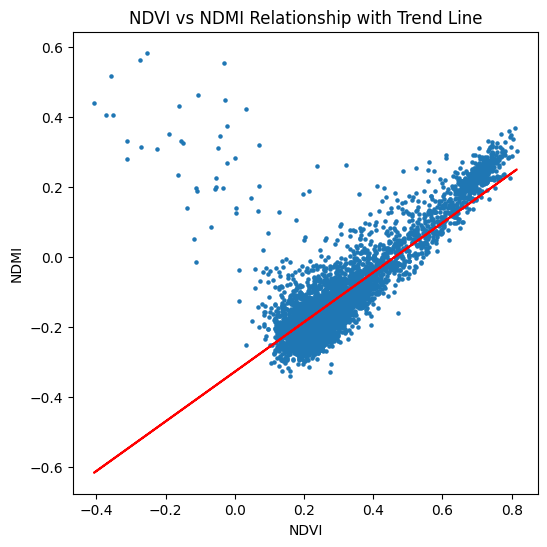

In [15]:
import numpy as np
import matplotlib.pyplot as plt

z = np.polyfit(df['NDVI'], df['NDMI'], 1)
p = np.poly1d(z)

plt.figure(figsize=(6,6))
plt.scatter(df['NDVI'], df['NDMI'], s=5)

plt.plot(df['NDVI'], p(df['NDVI']), color='red')

plt.xlabel("NDVI")
plt.ylabel("NDMI")
plt.title("NDVI vs NDMI Relationship with Trend Line")

plt.show()

In [20]:
task = ee.batch.Export.image.toDrive(
    image=dry.select('NDVI'),
    description='Buriram_NDVI',
    folder='GEE_exports',
    fileNamePrefix='buriram_ndvi',
    region=roi,
    scale=10,
    crs='EPSG:4326',
    fileFormat='GeoTIFF',
    maxPixels=1e13
)

task.start()

print(task.status())

{'state': 'READY', 'description': 'Buriram_NDVI', 'priority': 100, 'creation_timestamp_ms': 1774682336875, 'update_timestamp_ms': 1774682336875, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'HECSZKEMTOPBSLLMWJZCMPLN', 'name': 'projects/ee-chanita/operations/HECSZKEMTOPBSLLMWJZCMPLN'}
